# 04. IMS bearings: vibration features

**Module B**: run-to-failure vibration data from the IMS / University of Cincinnati bearing rig (NASA Prognostics Data Repository). Four Rexnord ZA-2115 double-row bearings sit on one shaft at 2,000 rpm under a 6,000 lb radial load, with accelerometers on each housing. Each file is a 1 s snapshot of 20,480 points, recorded about every 10 min.

| Test | Channels | Documented failure at end of test |
|---|---|---|
| 1 | 8 (2 per bearing) | bearing 3 **inner race**, bearing 4 **roller element** |
| 2 | 4 | bearing 1 **outer race** |
| 3 | 4 | bearing 3 **outer race** |

This notebook:
1. locates and inventories the three tests (the Kaggle folders are nested inconsistently),
2. derives the bearing defect frequencies from geometry and **checks the sampling rate against the data**,
3. shows what a defect looks like in the time, spectrum and envelope domains,
4. extracts features for all ~9,500 snapshots, one file at a time in parallel, never holding a whole test in memory.

In [1]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

from scipy.signal import butter, hilbert, sosfiltfilt
from compressor_guard.vibration.features import (defect_frequencies, extract_test_features, fault_freqs_from_params,
                                                  features_path)
from compressor_guard.vibration.io import KNOWN_FAILURES, find_test_folder, list_snapshots, load_snapshot

ims = params["ims"]

## 1. Inventory

In [2]:
inv = []
readme = {1: (2156, "2003-11-25 23:39"), 2: (984, "2004-02-19 06:22"), 3: (4448, "2004-04-04 19:01")}
for t in (1, 2, 3):
    s = list_snapshots(t, ims["raw_dir"])
    inv.append({"test": t, "folder": str(find_test_folder(t, ims["raw_dir"]).relative_to(ROOT)),
                "files": len(s), "readme_files": readme[t][0], "start": s["timestamp"].iloc[0],
                "end": s["timestamp"].iloc[-1], "readme_end": readme[t][1], "hours": round(s["hours"].iloc[-1], 1),
                "largest_gap_h": round(s["hours"].diff().max(), 1)})
display(pd.DataFrame(inv))

,test,folder,files,readme_files,start,end,readme_end,hours,largest_gap_h
0,1,data/raw/ims/1st_test/1st_test,2156,2156,2003-10-22 12:06:24,2003-11-25 23:39:56,2003-11-25 23:39,827.6,148.4
1,2,data/raw/ims/2nd_test/2nd_test,984,984,2004-02-12 10:32:39,2004-02-19 06:22:39,2004-02-19 06:22,163.8,0.2
2,3,data/raw/ims/3rd_test/4th_test/txt,6324,4448,2004-03-04 09:27:46,2004-04-18 02:42:55,2004-04-04 19:01,1073.3,7.5


Two data facts shape the rest of Module B:
- **Test 3 on disk runs to 18 Apr 2004 (6,324 files)**, two weeks past the readme's 4 Apr (4,448 files). This matches the widely used archive. We treat the last snapshot as the failure time.
- **Test 1 was stopped for ~148 h at hour 170** (the readme notes that larger timestamp gaps mean the experiment resumed on a later day). As notebook 05 shows, every bearing's vibration level shifted at the restart, a rig-level effect the health indicator must not mistake for damage.

## 2. Defect frequencies & sampling rate

For a rolling-element bearing with *n* rollers, pitch diameter *D*, roller diameter *d*, contact angle φ and shaft frequency *f_r*:

$$\text{BPFO} = \tfrac{n}{2} f_r \left(1 - \tfrac{d}{D}\cos\varphi\right),\quad
\text{BPFI} = \tfrac{n}{2} f_r \left(1 + \tfrac{d}{D}\cos\varphi\right),\quad
\text{BSF} = \tfrac{D}{2d} f_r \left(1 - \left(\tfrac{d}{D}\cos\varphi\right)^2\right),\quad
\text{FTF} = \tfrac{f_r}{2}\left(1 - \tfrac{d}{D}\cos\varphi\right)$$

In [3]:
g = ims["bearing_geometry"]
freqs = defect_frequencies(ims["shaft_speed_rpm"] / 60, g["n_rollers"], g["pitch_diameter_in"],
                           g["roller_diameter_in"], g["contact_angle_deg"])
display(pd.DataFrame({"computed_Hz": freqs, "config_Hz": ims["fault_frequencies_hz"]}).round(2))

,computed_Hz,config_Hz
bpfo,236.40,236.4
bpfi,296.93,296.9
bsf,139.92,139.9
ftf,14.78,14.8


The readme says both "20 kHz" and "20,480 points per 1 s snapshot", which can't both be true, and the difference moves every spectral line by 2.4 %. We let the data decide: test 2 bearing 1 fails with a known **outer-race** defect, so late in its life the envelope spectrum should peak at BPFO.

In [4]:
def envelope_spectrum(x, fs, band=(2000, 8000)):
    sos = butter(4, band, btype="band", fs=fs, output="sos")
    env = np.abs(hilbert(sosfiltfilt(sos, x - x.mean())))
    env -= env.mean()
    spec = np.abs(np.fft.rfft(env * np.hanning(len(env)))) / len(env)
    return np.fft.rfftfreq(len(env), 1 / fs), spec

s2 = list_snapshots(2, ims["raw_dir"])
late = [load_snapshot(p)[:, 0].astype(float) for p in s2["path"].iloc[int(len(s2) * 0.9): int(len(s2) * 0.9) + 10]]
early = [load_snapshot(p)[:, 0].astype(float) for p in s2["path"].iloc[10:20]]

rows = []
for fs in (20000, 20480):
    f, spec = envelope_spectrum(late[0], fs)
    spec = np.mean([envelope_spectrum(x, fs)[1] for x in late], axis=0)
    m = (f > 150) & (f < 400)
    peak = f[m][np.argmax(spec[m])]
    rows.append({"assumed_fs_Hz": fs, "envelope_peak_Hz": round(peak, 1), "BPFO_Hz": round(freqs["bpfo"], 1),
                 "error_%": round(100 * (peak - freqs["bpfo"]) / freqs["bpfo"], 2)})
display(pd.DataFrame(rows))

,assumed_fs_Hz,envelope_peak_Hz,BPFO_Hz,error_%
0,20000,230.5,236.4,-2.51
1,20480,236.0,236.4,-0.17


With fs = 20,480 Hz the dominant envelope line lands within ~0.2 % of the geometric BPFO; with 20 kHz it is 2.5 % low. We therefore use **fs = 20,480 Hz** (`params.yaml`). The ±5 % bands used for features would tolerate either, but the diagnosis is cleaner this way.

## 3. What a defect looks like (test 2, bearing 1)

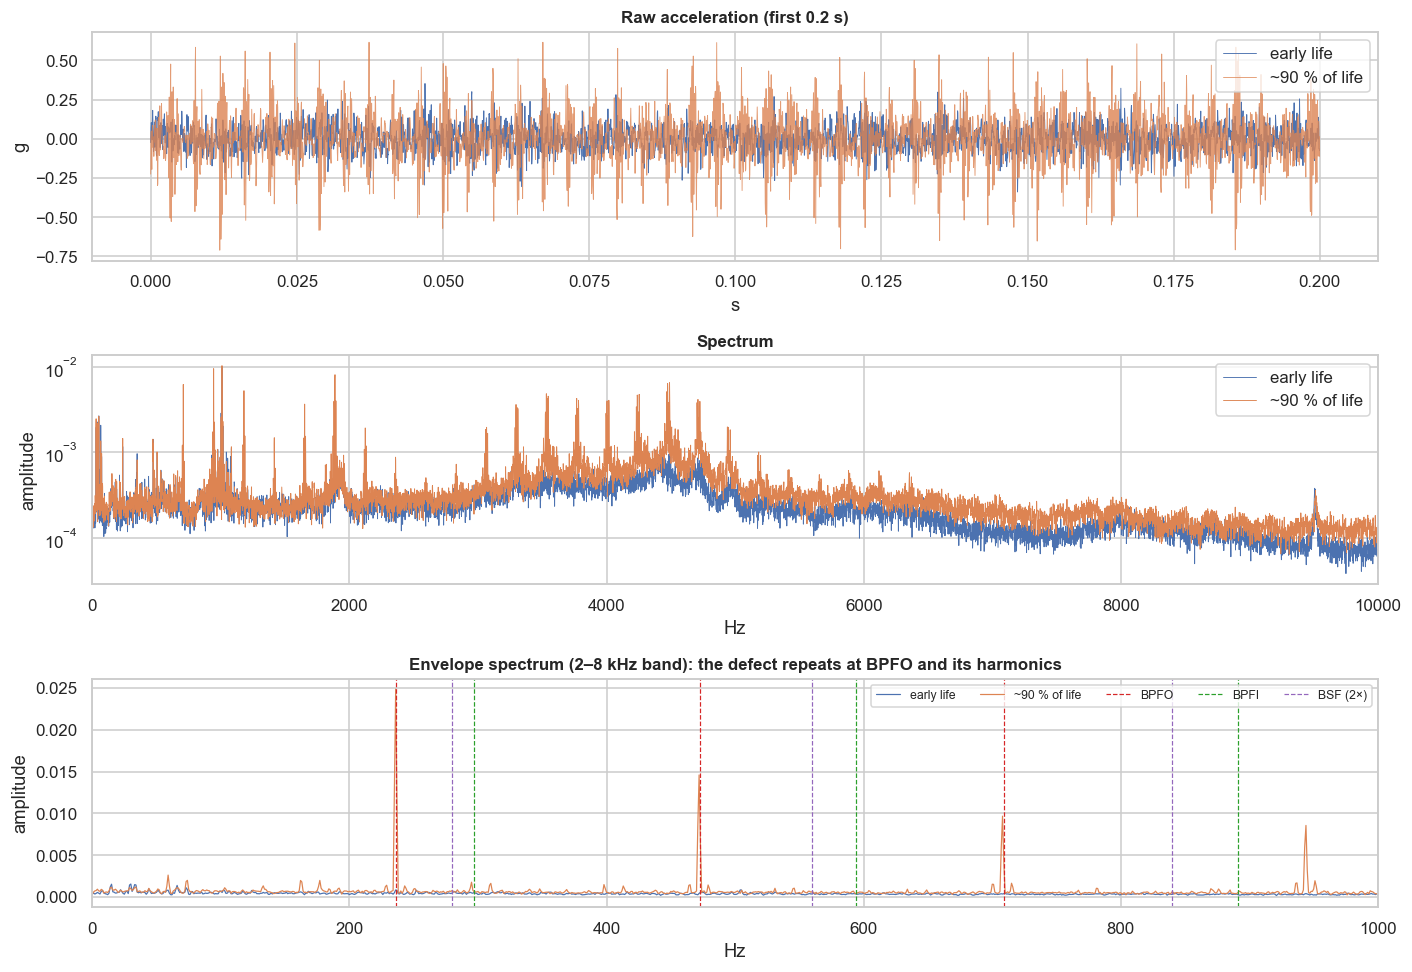

In [5]:
fs = ims["sampling_frequency_hz"]
t_ax = np.arange(len(late[0])) / fs
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
axes[0].plot(t_ax[:4096], early[0][:4096], lw=0.6, label="early life")
axes[0].plot(t_ax[:4096], late[0][:4096], lw=0.6, alpha=0.8, label="~90 % of life")
axes[0].set(title="Raw acceleration (first 0.2 s)", xlabel="s", ylabel="g"); axes[0].legend()

for x, lab in [(early, "early life"), (late, "~90 % of life")]:
    spec = np.mean([np.abs(np.fft.rfft(v * np.hanning(len(v)))) / len(v) for v in x], axis=0)
    f = np.fft.rfftfreq(len(x[0]), 1 / fs)
    axes[1].semilogy(f, spec, lw=0.6, label=lab)
    fe, se = envelope_spectrum(x[0], fs)
    se = np.mean([envelope_spectrum(v, fs)[1] for v in x], axis=0)
    axes[2].plot(fe, se, lw=0.8, label=lab)
axes[1].set(title="Spectrum", xlabel="Hz", ylabel="amplitude", xlim=(0, 10000)); axes[1].legend()
for k, c in [("bpfo", "#d62728"), ("bpfi", "#2ca02c"), ("bsf", "#9467bd")]:
    mult = 2 if k == "bsf" else 1
    for h in (1, 2, 3):
        axes[2].axvline(h * mult * freqs[k], color=c, ls="--", lw=0.8, label=f"{k.upper()}{' (2×)' if k == 'bsf' else ''}" if h == 1 else None)
axes[2].set(title="Envelope spectrum (2–8 kHz band): the defect repeats at BPFO and its harmonics",
            xlabel="Hz", ylabel="amplitude", xlim=(0, 1000)); axes[2].legend(ncol=5, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ims_envelope_spectrum.png")
plt.show()

The outer-race defect is invisible in the raw waveform's scale but obvious in the envelope spectrum: a comb at BPFO, 2×BPFO and 3×BPFO. This is why envelope analysis is the workhorse of bearing condition monitoring.

## 4. Feature extraction (all tests)

Per snapshot and channel (`vibration/features.py`):
- **time domain:** RMS, peak, peak-to-peak, crest factor, kurtosis, skewness
- **spectrum:** share of energy within ±5 % of the first three harmonics of BPFO, BPFI and 2×BSF, and above 5 kHz
- **envelope:** amplitude at BPFO, BPFI, 2×BSF and FTF, divided by the median envelope level (a unitless SNR)

The parquet files are reused if present. Set `RECOMPUTE = True` to rebuild them (~2 min on 8 cores).

In [6]:
RECOMPUTE = False
feats = {}
for t in (1, 2, 3):
    p = features_path(t, params)
    if RECOMPUTE or not p.exists():
        df = extract_test_features(t, params, n_jobs=-1)
        p.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(p, index=False)
    feats[t] = pd.read_parquet(p)
    print(f"test {t}: {feats[t]['timestamp'].nunique():,} snapshots x {feats[t].groupby(['bearing', 'channel']).ngroups} channels "
          f"-> {p.relative_to(ROOT)}")
feats[2].head()

test 1: 2,156 snapshots x 8 channels -> data/processed/ims_test1_features.parquet
test 2: 984 snapshots x 4 channels -> data/processed/ims_test2_features.parquet
test 3: 6,324 snapshots x 4 channels -> data/processed/ims_test3_features.parquet


,test,timestamp,hours,bearing,channel,rms,peak,p2p,crest,kurtosis,skewness,band_bpfo,band_bpfi,band_bsf,band_ftf,hf_energy,env_bpfo,env_bpfi,env_bsf,env_ftf
0,2,2004-02-12 10:32:39,0.000000,1,1,0.073475,0.464196,0.840,6.317747,3.628763,0.083993,0.017148,0.013147,0.017213,0.006119,0.162368,2.799486,2.258936,2.529233,4.826859
1,2,2004-02-12 10:42:39,0.166667,1,1,0.075338,0.385415,0.757,5.115803,3.648291,0.052142,0.023900,0.016665,0.017898,0.013004,0.178005,3.417854,1.919590,1.810706,2.643322
2,2,2004-02-12 10:52:39,0.333333,1,1,0.076189,0.505484,0.903,6.634581,3.513475,0.032808,0.012848,0.014816,0.015731,0.012792,0.160795,2.433723,1.900266,1.876782,5.794321
3,2,2004-02-12 11:02:39,0.500000,1,1,0.078691,0.610277,1.184,7.755379,4.157953,0.041486,0.012326,0.012370,0.013179,0.012119,0.159902,3.215933,2.255518,2.427311,4.238703
4,2,2004-02-12 11:12:39,0.666667,1,1,0.078437,0.393404,0.782,5.015510,3.603177,0.028224,0.015988,0.014628,0.014929,0.014131,0.156716,4.204752,2.784555,3.310980,6.127720


## 5. Degradation trajectories

Channel 1 of each bearing, with a trailing 1 h median. Failed bearings are drawn thick.

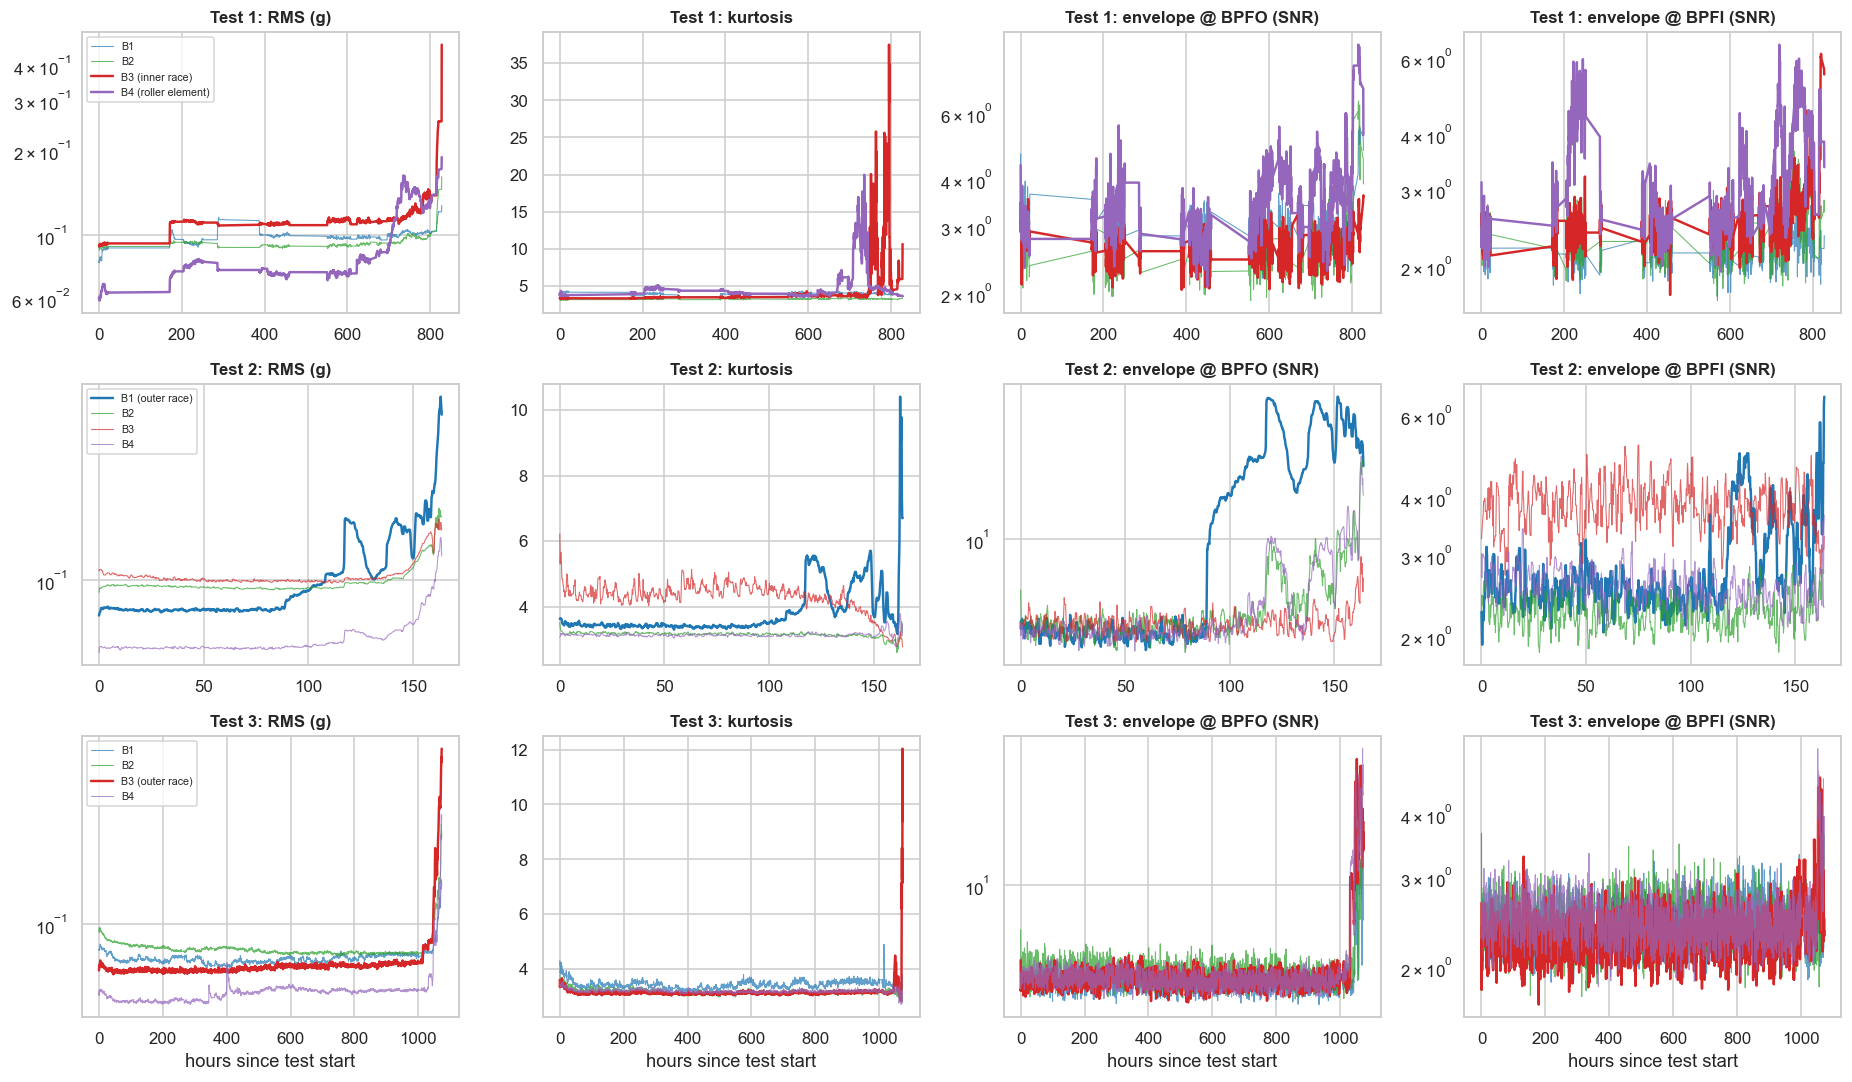

In [7]:
cols = [("rms", "RMS (g)"), ("kurtosis", "kurtosis"), ("env_bpfo", "envelope @ BPFO (SNR)"),
        ("env_bpfi", "envelope @ BPFI (SNR)")]
fig, axes = plt.subplots(3, 4, figsize=(17, 10))
palette = {1: "#1f77b4", 2: "#2ca02c", 3: "#d62728", 4: "#9467bd"}
for i, t in enumerate((1, 2, 3)):
    d = feats[t][feats[t]["channel"] == 1]
    for j, (c, lab) in enumerate(cols):
        ax = axes[i, j]
        for b, g in d.groupby("bearing"):
            failed = (t, b) in KNOWN_FAILURES
            ax.plot(g["hours"], g[c].rolling(6, min_periods=1).median(), color=palette[b],
                    lw=1.6 if failed else 0.7, alpha=1 if failed else 0.7,
                    label=f"B{b}" + (f" ({KNOWN_FAILURES[(t, b)].replace('_', ' ')})" if failed else ""))
        ax.set_title(f"Test {t}: {lab}")
        if c != "kurtosis":
            ax.set_yscale("log")
        if j == 0:
            ax.legend(fontsize=7, loc="upper left")
        if i == 2:
            ax.set_xlabel("hours since test start")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ims_features.png")
plt.show()

- **Test 2 B1 (outer race):** envelope BPFO jumps by an order of magnitude at ~hour 90, before RMS takes off. That is the classic early-warning pattern.
- **Test 3 B3 (outer race):** almost nothing until the final ~40 h, then a sharp envelope-BPFO and RMS rise. This bearing is known in the literature for late, abrupt degradation.
- **Test 1 B3/B4 (inner race / roller):** kurtosis and RMS climb over the last ~100–150 h. Note the level shift in *all* bearings around hour 170 (the restart).
- Near the end of each test, healthy bearings also rise slightly. Vibration from the failing bearing travels along the shaft (cross-talk).

Notebook 05 turns these features into a health indicator and handles the restart and cross-talk explicitly.